# Lab 03 - Exploratory Data Analysis (EDA): Pima Indians Diabetes

Notebook truyền thống (Jupyter/Colab) được chuyển từ phiên bản marimo.

Scope:
- Data loading + schema validation
- Data quality checks (NaN / duplicates / zero-as-missing)
- Univariate / bivariate visualization
- Correlation analysis
- Insight tổng kết + hướng sang preprocessing/modeling
- MCP-assisted parity notes


In [44]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception:
    widgets = None
    WIDGETS_AVAILABLE = False

plt.style.use('default')


In [45]:
column_names = [
    'pregnancies',
    'glucose',
    'blood_pressure',
    'skin_thickness',
    'insulin',
    'bmi',
    'diabetes_pedigree_function',
    'age',
    'outcome',
]
feature_columns = [c for c in column_names if c != 'outcome']
zero_as_missing_columns = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']
random_state = 42


In [46]:
def resolve_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'Lab_03' / 'data' / 'pima-indians-diabetes.csv').exists():
            return p
    raise FileNotFoundError('Cannot find Lab_03/data/pima-indians-diabetes.csv from current working tree')

repo_root = resolve_repo_root(Path.cwd())
data_path = repo_root / 'Lab_03' / 'data' / 'pima-indians-diabetes.csv'
names_path = repo_root / 'Lab_03' / 'data' / 'pima-indians-diabetes.names'

print('repo_root =', repo_root)
print('data_path =', data_path)


repo_root = c:\Users\Bao\OneDrive\Documents\GitHub\Nhom01_SGU26_ML
data_path = c:\Users\Bao\OneDrive\Documents\GitHub\Nhom01_SGU26_ML\Lab_03\data\pima-indians-diabetes.csv


In [47]:
df = pd.read_csv(data_path, header=None, names=column_names)

display(Markdown('## 1) Data Loading & Problem Definition'))
display(Markdown(f'- Shape: **{df.shape[0]} rows x {df.shape[1]} columns**\n- Bài toán: **binary classification**\n- Target: `outcome` (0 = negative, 1 = positive diabetes)'))


## 1) Data Loading & Problem Definition

- Shape: **768 rows x 9 columns**
- Bài toán: **binary classification**
- Target: `outcome` (0 = negative, 1 = positive diabetes)

In [48]:
df.head(10)


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [49]:
# Kiểm tra bị thiếu dữ liệu
df.isna().any()

pregnancies                   False
glucose                       False
blood_pressure                False
skin_thickness                False
insulin                       False
bmi                           False
diabetes_pedigree_function    False
age                           False
outcome                       False
dtype: bool

In [50]:
df.dtypes.to_frame(name='dtype')


,dtype
pregnancies,int64
glucose,int64
blood_pressure,int64
skin_thickness,int64
insulin,int64
bmi,float64
diabetes_pedigree_function,float64
age,int64
outcome,int64


In [51]:
cols = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree_function']

for col in cols:
    mean_val = df[df[col] != 0][col].mean()  # tính mean bỏ qua giá trị 0
    df[col] = df[col].replace(0, mean_val)

df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


In [52]:
class_counts = df['outcome'].value_counts().sort_index().rename('count')
class_rate = df['outcome'].value_counts(normalize=True).sort_index().rename('rate')
class_distribution = (
    class_counts.to_frame()
    .join(class_rate.to_frame())
    .assign(rate_pct=lambda x: (100 * x['rate']).round(2))
)

display(Markdown('## 2) Class Distribution'))
class_distribution


## 2) Class Distribution

,count,rate,rate_pct
outcome,,,
0,500,0.651042,65.1
1,268,0.348958,34.9


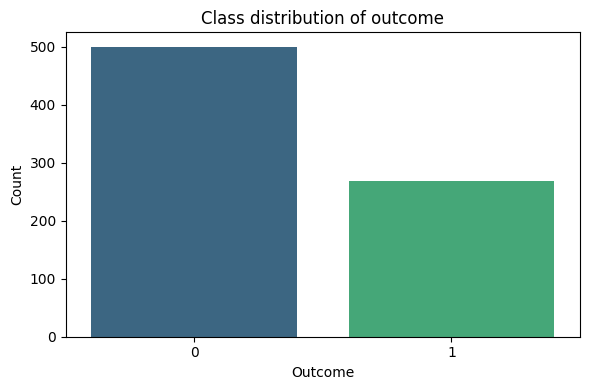

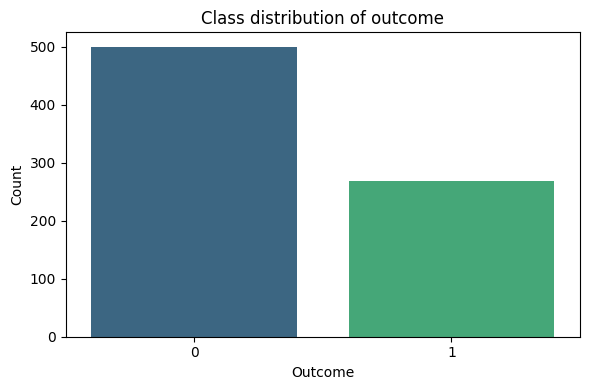

In [53]:
fig_class_dist, ax_class_dist = plt.subplots(figsize=(6, 4))
sns.barplot(
    x=class_distribution.index.astype(str),
    y=class_distribution['count'].values,
    ax=ax_class_dist,
    palette='viridis',
    hue=class_distribution.index.astype(str),
    legend=False,
)
ax_class_dist.set_title('Class distribution of outcome')
ax_class_dist.set_xlabel('Outcome')
ax_class_dist.set_ylabel('Count')
plt.tight_layout()
fig_class_dist


In [54]:
missing_report = pd.DataFrame(
    {
        'nan_count': df.isna().sum(),
        'nan_rate_pct': (100 * df.isna().mean()).round(2),
        'zero_count': (df == 0).sum(),
        'zero_rate_pct': (100 * (df == 0).mean()).round(2),
    }
)
duplicate_count = int(df.duplicated().sum())
duplicates_preview = df[df.duplicated()].head(10)
zero_focus_report = (
    missing_report.loc[zero_as_missing_columns + ['pregnancies', 'outcome']]
    .sort_values('zero_rate_pct', ascending=False)
    .copy()
)

df_masked = df.copy()
df_masked[zero_as_missing_columns] = df_masked[zero_as_missing_columns].replace(0, np.nan)

print('Duplicate rows:', duplicate_count)


Duplicate rows: 0


In [55]:
display(Markdown('## 3) Data Quality Checks'))
missing_report


## 3) Data Quality Checks

,nan_count,nan_rate_pct,zero_count,zero_rate_pct
pregnancies,0,0.0,111,14.45
glucose,0,0.0,0,0.00
blood_pressure,0,0.0,0,0.00
skin_thickness,0,0.0,0,0.00
insulin,0,0.0,0,0.00
bmi,0,0.0,0,0.00
diabetes_pedigree_function,0,0.0,0,0.00
age,0,0.0,0,0.00
outcome,0,0.0,500,65.10


In [56]:
display(Markdown('### Duplicate rows preview (nếu có)'))
duplicates_preview


### Duplicate rows preview (nếu có)

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome


In [57]:
zero_focus_report


,nan_count,nan_rate_pct,zero_count,zero_rate_pct
outcome,0,0.0,500,65.10
pregnancies,0,0.0,111,14.45
glucose,0,0.0,0,0.00
skin_thickness,0,0.0,0,0.00
blood_pressure,0,0.0,0,0.00
bmi,0,0.0,0,0.00
insulin,0,0.0,0,0.00


In [58]:
if WIDGETS_AVAILABLE:
    bins_slider = widgets.IntSlider(min=10, max=80, step=1, value=30, description='bins')
    feature_selector = widgets.Dropdown(options=feature_columns, value='glucose', description='feature')
    mask_zero_toggle = widgets.Checkbox(value=True, description='mask zero')
    pairplot_toggle = widgets.Checkbox(value=False, description='pairplot')
    display(widgets.HBox([bins_slider, feature_selector, mask_zero_toggle, pairplot_toggle]))
else:
    bins_slider = None
    feature_selector = None
    mask_zero_toggle = None
    pairplot_toggle = None
    display(Markdown('ipywidgets chưa khả dụng: dùng fallback parameters ở cell tiếp theo.'))


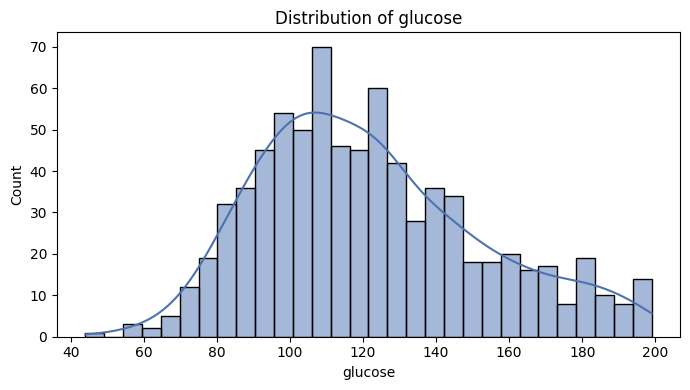

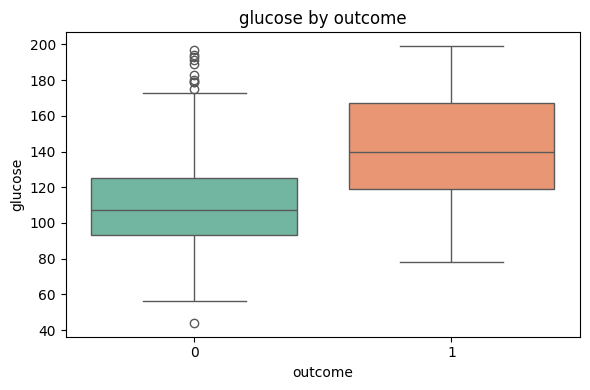

In [59]:
bins = 30
selected_feature = 'glucose'
use_zero_mask = True
enable_pairplot = False

if WIDGETS_AVAILABLE:
    bins = bins_slider.value
    selected_feature = feature_selector.value
    use_zero_mask = mask_zero_toggle.value
    enable_pairplot = pairplot_toggle.value

plot_df = df_masked if use_zero_mask else df

fig_hist, ax_hist = plt.subplots(figsize=(7, 4))
sns.histplot(data=plot_df, x=selected_feature, bins=bins, kde=True, ax=ax_hist, color='#4C72B0')
ax_hist.set_title(f'Distribution of {selected_feature}')
ax_hist.set_xlabel(selected_feature)
plt.tight_layout()
plt.show()

fig_box, ax_box = plt.subplots(figsize=(6, 4))
sns.boxplot(data=plot_df, x='outcome', y=selected_feature, ax=ax_box, palette='Set2', hue='outcome', legend=False)
ax_box.set_title(f'{selected_feature} by outcome')
ax_box.set_xlabel('outcome')
ax_box.set_ylabel(selected_feature)
plt.tight_layout()
plt.show()


In [60]:
display(Markdown('## 4) Descriptive Statistics'))

display(df[feature_columns].describe().T)

grouped_stats = df.groupby('outcome')[feature_columns].agg(['mean', 'median', 'std', 'max', 'min']).round(3)
grouped_stats


## 4) Descriptive Statistics

,count,mean,std,min,25%,50%,75%,max
pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.000000,6.000000,17.00
glucose,768.0,121.686763,30.435949,44.000,99.75000,117.000000,140.250000,199.00
blood_pressure,768.0,72.405184,12.096346,24.000,64.00000,72.202592,80.000000,122.00
skin_thickness,768.0,29.153420,8.790942,7.000,25.00000,29.153420,32.000000,99.00
insulin,768.0,155.548223,85.021108,14.000,121.50000,155.548223,155.548223,846.00
bmi,768.0,32.457464,6.875151,18.200,27.50000,32.400000,36.600000,67.10
diabetes_pedigree_function,768.0,0.471876,0.331329,0.078,0.24375,0.372500,0.626250,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.000000,41.000000,81.00


pregnancies                        glucose                        \
               mean median    std max min     mean median     std    max   
outcome                                                                    
0             3.298    2.0  3.017  13   0  110.710  107.5  24.717  197.0   
1             4.866    4.0  3.741  17   0  142.166  140.0  29.542  199.0   

               ... diabetes_pedigree_function                              \
          min  ...                       mean median    std    max    min   
outcome        ...                                                          
0        44.0  ...                       0.43  0.336  0.299  2.329  0.078   
1        78.0  ...                       0.55  0.449  0.372  2.420  0.088   

            age                         
           mean median     std max min  
outcome                                 
0        31.190   27.0  11.668  81  21  
1        37.067   36.0  10.968  70  21  

[2 rows x 40 columns]

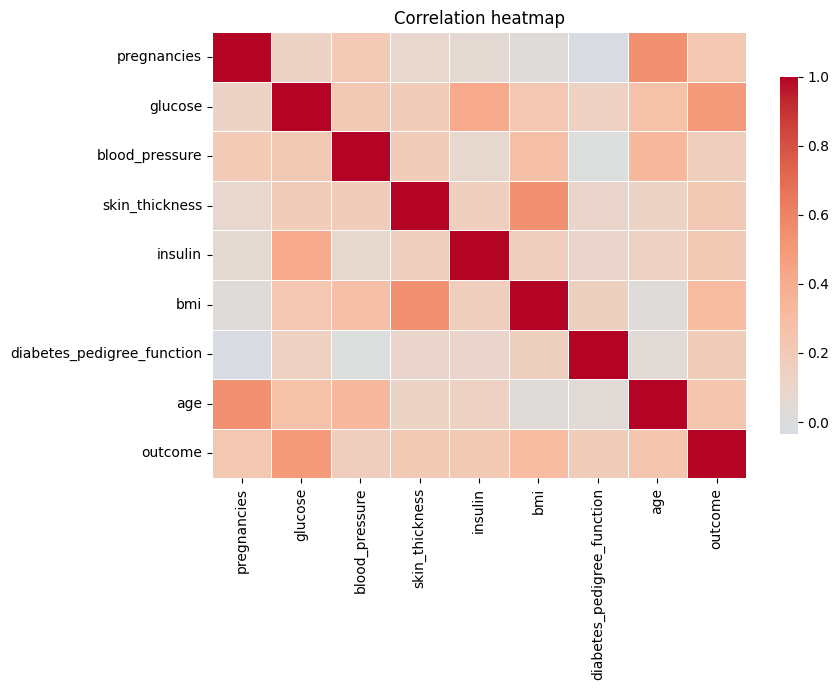

,corr_with_outcome
outcome,1.000000
glucose,0.492928
bmi,0.311924
age,0.238356
pregnancies,0.221898
skin_thickness,0.215299
insulin,0.214411
diabetes_pedigree_function,0.173844
blood_pressure,0.166074


In [61]:
corr_source = df_masked if use_zero_mask else df
corr_matrix = corr_source.corr(numeric_only=True)

fig_corr, ax_corr = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.4,
    cbar_kws={'shrink': 0.8},
    ax=ax_corr,
)
ax_corr.set_title('Correlation heatmap')
plt.tight_layout()
plt.show()

corr_matrix['outcome'].sort_values(ascending=False).to_frame(name='corr_with_outcome')


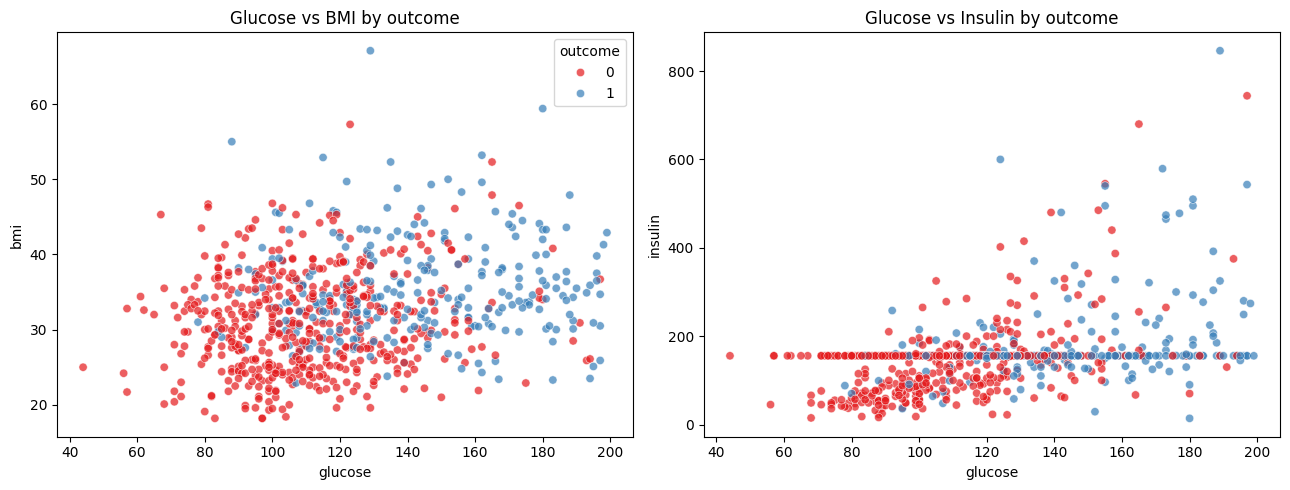

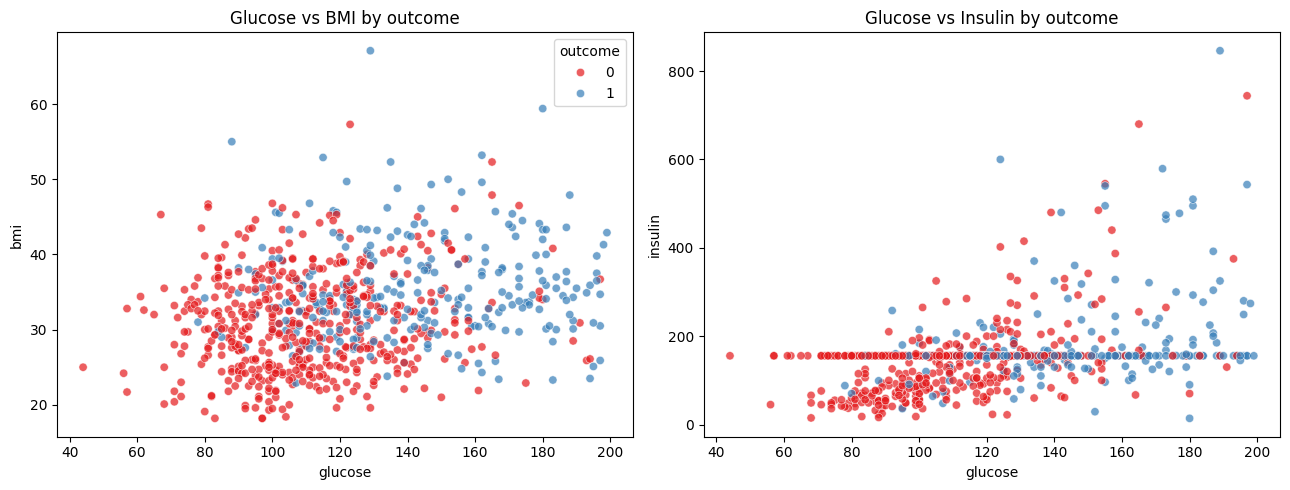

In [62]:
fig_scatter, axes_scatter = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=corr_source, x='glucose', y='bmi', hue='outcome', alpha=0.7, ax=axes_scatter[0], palette='Set1')
axes_scatter[0].set_title('Glucose vs BMI by outcome')

sns.scatterplot(data=corr_source, x='glucose', y='insulin', hue='outcome', alpha=0.7, ax=axes_scatter[1], palette='Set1', legend=False)
axes_scatter[1].set_title('Glucose vs Insulin by outcome')

plt.tight_layout()
fig_scatter


In [63]:
if enable_pairplot:
    pairplot_df = corr_source[['glucose', 'bmi', 'age', 'insulin', 'outcome']].dropna()
    grid = sns.pairplot(pairplot_df, hue='outcome', diag_kind='kde', corner=True)
    grid.fig.suptitle('Pairplot for selected features', y=1.02)
    plt.show()
else:
    print('Pairplot đang tắt (enable_pairplot=False hoặc widget pairplot=False).')


Pairplot đang tắt (enable_pairplot=False hoặc widget pairplot=False).


In [64]:
top_zero_cols = zero_focus_report.index[:3].tolist()
summary_md = (
    f"- Dataset có **{int(class_distribution['count'].sum())}** quan sát, target lệch lớp vừa phải\n"
    f"  (class 0 khoảng **{class_distribution.loc[0, 'rate_pct']:.2f}%**, class 1 khoảng **{class_distribution.loc[1, 'rate_pct']:.2f}%**).\n"
    f"- Số dòng trùng lặp phát hiện: **{duplicate_count}**.\n"
    f"- Các cột có tỷ lệ `0` cao nhất (gợi ý missing ngầm): **{', '.join(top_zero_cols)}**.\n"
    "- Khi chuyển `0 -> NaN` ở các cột sinh lý (`glucose`, `blood_pressure`, `skin_thickness`, `insulin`, `bmi`),\n"
    "  ma trận tương quan và phân bố thường phản ánh dữ liệu thực tế hơn.\n"
    "- Bước tiếp theo: tách train/test có stratify, thử imputation pipeline và baseline model."
)

display(Markdown('## 5) EDA Insights Summary'))
display(Markdown(summary_md))


## 5) EDA Insights Summary

- Dataset có **768** quan sát, target lệch lớp vừa phải
  (class 0 khoảng **65.10%**, class 1 khoảng **34.90%**).
- Số dòng trùng lặp phát hiện: **0**.
- Các cột có tỷ lệ `0` cao nhất (gợi ý missing ngầm): **outcome, pregnancies, glucose**.
- Khi chuyển `0 -> NaN` ở các cột sinh lý (`glucose`, `blood_pressure`, `skin_thickness`, `insulin`, `bmi`),
  ma trận tương quan và phân bố thường phản ánh dữ liệu thực tế hơn.
- Bước tiếp theo: tách train/test có stratify, thử imputation pipeline và baseline model.

In [65]:
# Kiểm tra bị thiếu dữ liệu
df.isna().any()

pregnancies                   False
glucose                       False
blood_pressure                False
skin_thickness                False
insulin                       False
bmi                           False
diabetes_pedigree_function    False
age                           False
outcome                       False
dtype: bool

In [74]:
from sklearn.model_selection import train_test_split

# X (features) và y (label)
X = df.drop("outcome", axis=1)
y = df["outcome"]

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [75]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

# Tách X, y
X = df.drop("outcome", axis=1)
y = df["outcome"]

# Chọn top k đặc trưng
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

# Xem feature được chọn
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)

# Train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42, stratify=y
)

Selected features: Index(['pregnancies', 'glucose', 'skin_thickness', 'bmi', 'age'], dtype='str')


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    #"Logistic Regression": LogisticRegression(max_iter=1000),
    #"Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    #"KNN": KNeighborsClassifier()
    "GaussianNB": GaussianNB()
}
# Train model
rf = RandomForestClassifier()
rf.fit(X, y)

# Train
for name, model in models.items():
    model.fit(X_train, y_train)

In [77]:
from sklearn.metrics import accuracy_score, classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

=== Random Forest ===
Accuracy: 0.7207792207792207
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       100
           1       0.60      0.59      0.60        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154

=== SVM ===
Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.75      0.87      0.81       100
           1       0.66      0.46      0.54        54

    accuracy                           0.73       154
   macro avg       0.70      0.67      0.67       154
weighted avg       0.72      0.73      0.71       154

=== GaussianNB ===
Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       100
           1       0.57      0.57      0.57        54

    accuracy                           0.7